In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import rioxarray as rio
import rasterio as ras
import matplotlib.pyplot as plt

In [2]:
# Loading the Baldwin County shapefile
usa_counties = gpd.read_file(r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\tl_2025_us_county\tl_2025_us_county.shp")
baldwin = usa_counties[usa_counties['GEOID'] == '01003']

In [3]:
years = [2015, 2018, 2022, 2025]
# Green is Band 3, Red is Band 4, NIR is Band 5, and SWIR is Band 6
landsat_data = {
    2015: {
        "green": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B3.TIF",
        "red": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B4.TIF",
        "nir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B5.TIF",
        "swir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B6.TIF",
    },
    2018: {
        "green": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2018\LC08_L2SP_020039_20181116_20200830_02_T1_SR_B3.TIF",
        "red": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2018\LC08_L2SP_020039_20181116_20200830_02_T1_SR_B4.TIF",
        "nir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2018\LC08_L2SP_020039_20181116_20200830_02_T1_SR_B5.TIF",
        "swir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2018\LC08_L2SP_020039_20181116_20200830_02_T1_SR_B6.TIF",
    },
    2022: {
        "green": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2022\LC09_L2SP_020039_20221002_20230327_02_T1_SR_B3.TIF",
        "red": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2022\LC09_L2SP_020039_20221002_20230327_02_T1_SR_B4.TIF",
        "nir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2022\LC09_L2SP_020039_20221002_20230327_02_T1_SR_B5.TIF",
        "swir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2022\LC09_L2SP_020039_20221002_20230327_02_T1_SR_B6.TIF",
    },
    2025: {
        "green": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2025\LC09_L2SP_020039_20251127_20251129_02_T1_SR_B3.TIF",
        "red": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2025\LC09_L2SP_020039_20251127_20251129_02_T1_SR_B4.TIF",
        "nir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2025\LC09_L2SP_020039_20251127_20251129_02_T1_SR_B5.TIF",
        "swir": r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2025\LC09_L2SP_020039_20251127_20251129_02_T1_SR_B6.TIF",
    }
}

In [4]:
def classify_land_cover(ndvi, ndwi, ndbi):
    """
    This function determines land use land cover (LULC) using NDVI, NDWI, and NDBI threshold values.

    Parameters:
    -----------------
    ndvi: numpy.ndarray
    An array for Normalized Difference Vegetation Index. Higher NDVI values indicate a parcel of land has dense vegetation.

    ndwi: numpy.ndarray
    An array for Normalized Difference Water Index. Higher NDWI values indicate a region has bodies of water such as rivers, ponds, and lakes.

    ndbi: numpy.ndarray
    An array for Normalized Difference Built-up Index. Higher NDBI values indicate an area is "built-up", in other words, urbanized.

    Returns:
    -----------------
    numpy.ndarray
        An array of classified LULC with the following labels:
            0: Vegetation
            1: Built-up
            2: Water
            3: Unused Land
    """
    lulc = np.zeros(ndvi.shape) # creates a new array with the same dimensions as the ndvi array

    # Water classification
    lulc = np.where(ndwi > 0.3, 2, lulc) # #np.where is basically like an if statement. If a pixel has NDWI > 0.3, then it gets labeled as water (2). If not, then the pixel remains unclassified.

    # Vegetation classification
    lulc = np.where(ndvi > 0.4, 0, lulc)

    # Urban classification
    lulc = np.where((ndbi > 0.2 & ndvi < 0.3), 1, lulc) # the & statement is needed so areas of low-vegetation are filtered because urbanized areas don't have much vegetation

    # Unused land classification
    lulc = np.where((ndvi < 0.3) & (ndbi < 0.2) & (ndwi < 0.3), 3, lulc) # Unused land has no buildings, dense vegetation, or bodies of water

    return lulc

In [14]:
# TESTING
green = rio.open_rasterio(r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B3.TIF").rio.reproject("EPSG:4326")
red = rio.open_rasterio(r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B4.TIF").rio.reproject("EPSG:4326")
nir = rio.open_rasterio(r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B5.TIF").rio.reproject("EPSG:4326")
swir = rio.open_rasterio(r"C:\Users\andre\OneDrive\Documents\schoolstuff\AES408\Final_Project\Baldwin_2015\LC08_L2SP_020039_20150124_20200910_02_T1_SR_B6.TIF").rio.reproject("EPSG:4326")

In [15]:
# template for calculating these values when I load in the image data later
red = (red * 0.0000275 - 0.2).astype("float32")
nir = (nir * 0.0000275 - 0.2).astype("float32")
green = (green * 0.0000275 - 0.2).astype("float32")
swir = (swir * 0.0000275 - 0.2).astype("float32")
ndvi = (nir - red) / (nir + red)
ndwi = (green - nir) / (green + nir)
ndbi = (swir - nir) / (swir + nir)

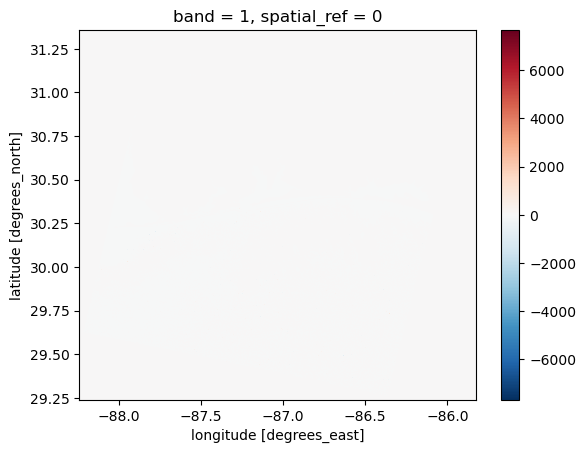

In [16]:
ndvi.plot()